In [13]:
from typing_extensions import TypedDict
from langgraph.graph import START, END, StateGraph
from langchain_anthropic import ChatAnthropic
from dotenv import load_dotenv

load_dotenv()

True

In [14]:
model = ChatAnthropic(model_name="claude-haiku-4-5-20251001")

In [15]:
class ParentState(TypedDict):
    question: str
    answer_eng: str
    answer_hin: str

In [20]:
def translate_text(state: ParentState):
    prompt = f"""
        Translate the following text to Hindi.
        Keep it natural and clear. Do not add extra content.

        Text:
        {state["answer_eng"]}
        """.strip()
    
    translated_text = model.invoke(prompt).content

    return {"answer_hin": translated_text}

def generate_answer(state: ParentState):
    answer = model.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

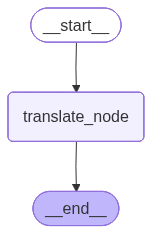

In [21]:
subgraph = StateGraph(ParentState)

subgraph.add_node("translate_node", translate_text)

subgraph.add_edge(START, "translate_node")
subgraph.add_edge("translate_node", END)

translate_subgraph = subgraph.compile()

translate_subgraph

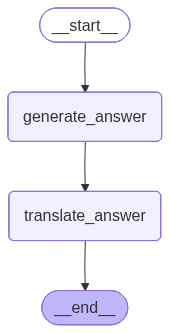

In [22]:
graph = StateGraph(ParentState)

graph.add_node("generate_answer", generate_answer)
graph.add_node("translate_answer", translate_subgraph)

graph.add_edge(START, "generate_answer")
graph.add_edge("generate_answer", "translate_answer")
graph.add_edge("translate_answer", END)

graph = graph.compile()

graph

In [23]:
graph.invoke({"question": "What is the capital of India?"})

{'question': 'What is the capital of India?',
 'answer_eng': 'The capital of India is **New Delhi**.\n\nNew Delhi is located in the northern part of India and serves as the seat of the Indian government. It is part of the larger Delhi metropolitan area.',
 'answer_hin': 'भारत की राजधानी **नई दिल्ली** है।\n\nनई दिल्ली भारत के उत्तरी भाग में स्थित है और भारतीय सरकार की सीट के रूप में कार्य करती है। यह बड़े दिल्ली महानगरीय क्षेत्र का हिस्सा है।'}